In [ ]:
# 비지도학습 -> 오토인코더 모델 많이 활용  y가 없고 x만 
# 정상만을 학습 하고 값을 넣었을때 정상과 얼마나 오차(차이)가 있는지 값을 통해서 정상인지 아닌지를 판별 

In [1]:
# ============================================================
# 1. 라이브러리 호출
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

np.random.seed(42)
tf.random.set_seed(42)

In [6]:
# ============================================================
# 2. 가상 센서 데이터 생성
# ============================================================

n_normal = 5000   # 정상데이터 샘플 수
n_anomaly = 500   # 이상 데이터 샘플 수
n_features = 4    # 센서 개수

# 정상 데이터 : 평균 0 , 표준편차 1인 정규분포내에서 값을 샘플링하여 센서데이터 생성
normal_data = np.random.normal(loc=0.0, scale=1.0, size=(n_normal, n_features))

# 이상 데이터 : 평균을 크게 이동시키고, 분산을 키워서 비정상적인 패턴의 센서 데이터 생성
anomal_data = np.random.normal(loc=3.0, scale=1.5, size=(n_anomaly, n_features))

X = np.vstack([normal_data, anomal_data])              # 정상과 이상 데이터를 위 아래로 이어 붙임
y = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)]) # 정상은 0, 이상은 1로 레이블 벡터를 만듬

In [7]:
anomal_data

array([[ 1.97097613,  3.50942941, -0.3309915 ,  1.34575782],
       [ 0.2064434 ,  2.79156523,  5.037961  ,  3.39040436],
       [ 3.88936442,  2.65190616,  3.01711703,  0.31057306],
       ...,
       [ 3.05923505,  1.3109221 ,  2.17362665,  2.34553244],
       [ 3.56029539,  4.08987664,  4.41574594,  5.85896931],
       [ 4.41871229,  4.18638749,  1.00744168,  0.5832423 ]],
      shape=(500, 4))

In [8]:
normal_data

array([[-0.29315172, -0.99753196,  0.89527097, -0.39126718],
       [-0.7263633 , -1.68959909,  1.68221583, -1.55441846],
       [ 0.2869766 ,  0.66192051, -0.38760856,  0.41921054],
       ...,
       [-0.74383059,  0.54982635,  0.24343426, -0.58943621],
       [ 0.87581506,  0.11412241,  1.07317412,  1.41886038],
       [-1.09527763,  1.6859811 ,  0.5518541 ,  0.31036316]],
      shape=(5000, 4))

In [11]:
# ============================================================
# 3. 학습/테스트 데이터 분리 (70%/30%)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 이상 탐지 autoencoder는 정상데이터로만 학습하므로 정상 샘플만 필터링 
X_train_normal = X_train[y_train == 0]  #레이블이 0(정상)인 데이터만 x 데이터로 필터링

In [13]:
# ============================================================
# 4. 데이터 스케일링 (표준화)
# ============================================================
scaler = StandardScaler()           # 평균 0, 분산 1 로 맞추는 표준화 객체 생성 
scaler.fit(X_train_normal)          # 정상 학습 데이터로 표준화 기준 적용

X_train_normal_scaled = scaler.transform(X_train_normal) #학습용 정상 데이터를 표준화 
X_test_scaled = scaler.transform(X_test)                 #테스트 데이터를 표준화 

In [18]:
# ============================================================
# 5. Autoencoder 모델 정의
# ============================================================

input_dim = 4                       # 입력 차원을 센서 개수와 동일하게 설정
encoding_dim = 2                    # 잠재공간(Latent space) 2차원으로 설정해서 압축을 진행

# 입력 레이어 정의, 입력 크기는 센서 개수와 동일하게 설정
input_layer = layers.Input(shape=(input_dim,), name='input')

# 인코더 부분 : 입력을 더 작은 차원(2차원)으로 압축하는 레이어
encoded = layers.Dense(8, activation='relu', name='encoder_dense1')(input_layer)   # 8개의 뉴런으로 첫 번째 레이어 구성
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder_dense2')(encoded)  # 2차원 잠재 표현으로 압축

# 디코더 : 압축된 표현을 다시 원래 차원으로 복원하는 레이어
decoded = layers.Dense(8, activation='relu', name='decoder_dense1')(encoded)       # 8개의 뉴런으로 복원을 하는 중간 레이어 구성
decoded = layers.Dense(input_dim, activation='linear', name='decoder_output')(decoded)  # 원래 입력 차원으로 복원하며 출력

# 입력부터 출력까지를 연결해주는 autoencoder 모델 구성
autoencoder = models.Model(inputs=input_layer, outputs=decoded, name='autoencoder_model')

# 모델 구조 출력
autoencoder.summary()

Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense1 (Dense)               │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense2 (Dense)               │ (None, 2)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense1 (Dense)               │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_output (Dense)               │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# 6. Autoencoder 모델 컴파일 설정 
# ============================================================

autoencoder.compile(
    optimizer = 'adam',   # 최적화 알고리즘은 adam 사용
    loss='mse'            # 입력과 복원된 출력의 차이를 제곱오차로 계산 
)

# 이상탐지의 경우 재구성 오차를 줄이는 방향으로 확실히 학습함 



In [20]:
# ============================================================
# 7. Autoencoder 학습
# ============================================================

# 정상 데이터만 사용해서 학습 수행 

history = autoencoder.fit(
    X_train_normal_scaled,           # 입력과 타겟이 동일한 정상 데이터를 사용
    X_train_normal_scaled,           # 입력을 그대로 복원 하도록 학습
    epochs=70,                       # 70번 반복학습 
    batch_size=64,                   # 머니배치 크기 64
    validation_split=0.2,            # 학습데이터의 20% 검증
    verbose=1                        # 학습진행상황 로그 출력 
)

Epoch 1/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.9927 - val_loss: 0.9666
Epoch 2/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9673 - val_loss: 0.9363
Epoch 3/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9303 - val_loss: 0.8947
Epoch 4/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8870 - val_loss: 0.8547
Epoch 5/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8538 - val_loss: 0.8292
Epoch 6/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8343 - val_loss: 0.8142
Epoch 7/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8225 - val_loss: 0.8041
Epoch 8/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8142 - val_loss: 0.7964
Epoch 9/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8079 - val_loss: 0.7901
Epoch 10/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8026 - val_loss: 0.7847
Epoch 11/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7981 - val_loss: 0.7799
Epoch 12/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7940 - val_lo

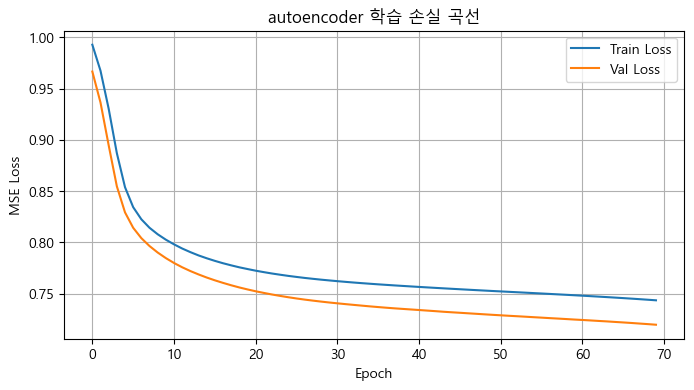

In [21]:
#==========================================================
# 8. 학습과정 시각화 (loss) 
#==========================================================

# 그래프 한글 폰트 설정
from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'          # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False             # 마이너스 부호 깨짐 방지

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('autoencoder 학습 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#==========================================================
# 9. 테스트 데이터에서 재구성 오차 계산 
#==========================================================

X_test_pred = autoencoder.predict(X_test_scaled)                                 # 테스트 데이터를 autoncoder 모델에 통과 시켜서 복원값을 얻어옴 
reconstruction_err = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)
# 각 샘플에 대해서 (입력 - 복원값)^2를 계산하고 , 특정 차원 방향으로 평균을 내서 재구성 오차를 구함 

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [30]:
# ============================================================
# 10. 이상 탐지 임계값(threshold) 설정
# ============================================================

# 정상 학습 데이터의 재구성 오차 분포를 기반으로 임계값 설정
X_train_pred = autoencoder.predict(X_train_normal_scaled)  # <-- 정상 학습데이터의 복원값 구하고,
train_reconstruction_error = np.mean(                      # <-- 재구성 오차(복원 오차)를 계산
    np.square(X_train_normal_scaled - X_train_pred), axis = 1
)

# 정상 오차의 95%값을 임계값으로 설정
threshold = np.percentile(train_reconstruction_error, 95)
print('이상 감지 임계값(95%) : ', threshold)

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step
이상 감지 임계값(95%) :  1.9326532777442613


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
재구성 오차 기반 ROC-AUC :  0.9964


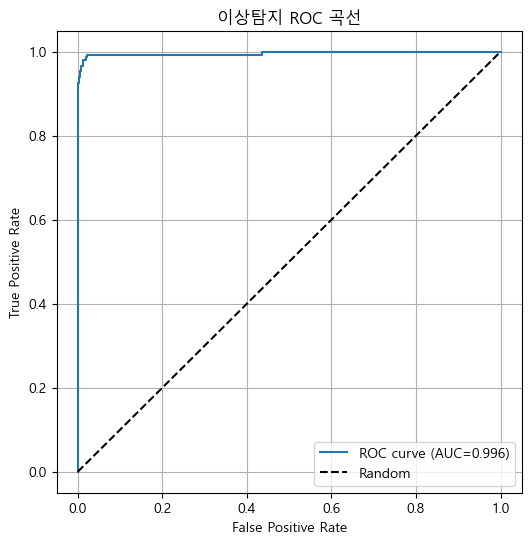

In [32]:
#===========================================================
# 11. 이상 여부 예측 및 ROC-AUC 평가
#===========================================================

# 테스트 데이터를 Autoencoder로 복원
X_test_pred = autoencoder.predict(X_test_scaled)

# 테스트 데이터의 재구성 오차 계산
reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_pred), axis=1
)

# 재구성 오차가 임계값보다 크면 이상(1), 작으면 정상(0)으로 예측 데이터를 만듬
y_pred_anomaly = (reconstruction_error > threshold).astype(int)

# 재구성 오차를 점수로 사용하여 ROC-AUC를 계산해서 이상탐지 성능 측정
auc = roc_auc_score(y_test, reconstruction_error)
print('재구성 오차 기반 ROC-AUC : ', auc)

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)  # roc 곡선을 그리기 위해 FPR, TPR 값을 계산

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc:.3f})')    # FPR-TPR 곡선을 그리고 AUC를 표시
plt.plot([0,1], [0,1], 'k--', label='Random')             # 무작위 분류 기준선(대각선)을 점선으로 그리기
plt.xlabel('False Positive Rate')                         # X축 라벨을 거짓양성률 설정
plt.ylabel('True Positive Rate')                          # Y축 라벨을 진성률로 설정
plt.title('이상탐지 ROC 곡선')
plt.legend()
plt.grid(True)
plt.show()

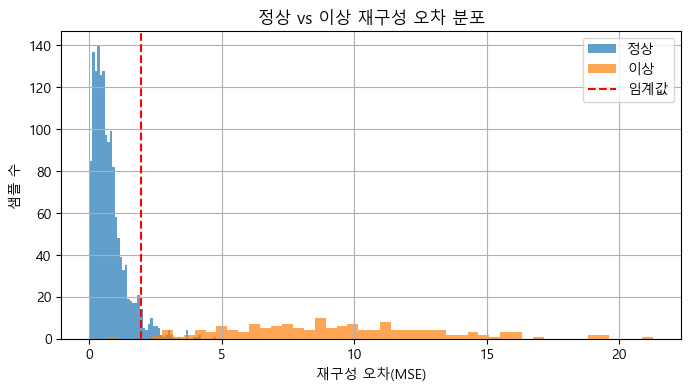

In [33]:
#===========================================================
# 12. 재구성 오차 분포 시각화
#===========================================================

plt.figure(figsize=(8,4))
plt.hist(reconstruction_error[y_test == 0], bins=50, alpha=0.7, label='정상')  # 정상 샘플 오차 분포 그리기
plt.hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7, label='이상')  # 이상 샘플 오차 분포 그리기
plt.axvline(threshold, color='red', linestyle='--', label='임계값')            #
plt.title('정상 vs 이상 재구성 오차 분포')
plt.xlabel('재구성 오차(MSE)')
plt.ylabel('샘플 수')
plt.legend()
plt.grid(True)
plt.show()